# Step 3: Data Preprocessing, Applied EDA & Feature Engineering
**Capstone Project — Cybersecurity: Detect Anomalies in Network Traffic**

Dataset: CICIDS2017  
This notebook covers:
1. Data cleaning (nulls, Inf values, duplicates, zero-variance drop)
2. Outlier treatment (log transformation, robust scaling)
3. Feature engineering (domain-derived features, encoding, binning)
4. Applied EDA (distributions, correlations, attack-type patterns)
5. Feature importance via SHAP
6. Feature selection (variance threshold + correlation filter + SHAP-based)
7. Dimensionality reduction (PCA + t-SNE)

## 1. Setup & Imports

In [1]:
# Install required libraries (Colab)
!pip install shap umap-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import shap
import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2. Reload Dataset

Run the Kaggle setup and download cells from Step 2 first, or mount your Drive if the files are already there.
This cell reloads from the same `./cicids2017/` directory used in Step 2.

In [3]:
# ── Kaggle API Setup (skip if dataset already downloaded) ──────────────────────
import json as _json
from google.colab import files

if not os.path.exists(os.path.expanduser('~/.kaggle/kaggle.json')):
    print('kaggle.json not found — uploading now...')
    uploaded = files.upload()
    if 'kaggle.json' in uploaded:
        creds = _json.loads(uploaded['kaggle.json'])
        kaggle_dir = os.path.expanduser('~/.kaggle')
        os.makedirs(kaggle_dir, exist_ok=True)
        with open(os.path.join(kaggle_dir, 'kaggle.json'), 'wb') as f:
            f.write(uploaded['kaggle.json'])
        os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)
        print(f'Authenticated as: {creds["username"]}')
    else:
        raise FileNotFoundError('Upload kaggle.json to proceed.')
else:
    print('kaggle.json already configured.')

kaggle.json not found — uploading now...


Saving kaggle.json to kaggle.json
Authenticated as: jairuchan


In [4]:
# ── Download dataset if not already present ───────────────────────────────────
import subprocess

if not os.path.exists('./cicids2017') or len(glob.glob('./cicids2017/**/*.csv', recursive=True)) == 0:
    os.makedirs('./cicids2017', exist_ok=True)
    mirrors = [
        'chethuhn/network-intrusion-dataset',
        'naveengill/cicids2017-dataset',
    ]
    for mirror in mirrors:
        r = subprocess.run(
            ['kaggle', 'datasets', 'download', '-d', mirror, '--unzip', '-p', './cicids2017'],
            capture_output=True, text=True
        )
        if r.returncode == 0:
            print(f'Downloaded: {mirror}')
            break
        print(f'Failed: {mirror} — {r.stderr.strip()[:80]}')
else:
    print('Dataset already present — skipping download.')

Downloaded: chethuhn/network-intrusion-dataset


In [5]:
# ── Load & stratified-sample (same logic as Step 2) ───────────────────────────
SAMPLE_SIZE = 500_000

def optimise_dtypes(df):
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    return df

csv_files = sorted(glob.glob('./cicids2017/**/*.csv', recursive=True))
print(f'Found {len(csv_files)} CSV files.')

dfs = []
for f in csv_files:
    df_part = pd.read_csv(f, encoding='utf-8', low_memory=False)
    df_part.columns = df_part.columns.str.strip()
    df_part['source_file'] = os.path.basename(f)
    df_part = optimise_dtypes(df_part)
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)
del dfs

# Remove duplicate column (known CICIDS2017 issue)
df = df.loc[:, ~df.columns.duplicated()]

# Normalise label strings
df['Label'] = df['Label'].astype(str).str.strip()

# Stratified sample
if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    df = (
        df.groupby('Label', group_keys=False)
          .apply(lambda x: x.sample(
              min(len(x), max(1, int(SAMPLE_SIZE * len(x) / len(df)))),
              random_state=RANDOM_SEED
          ))
          .reset_index(drop=True)
    )

# Attack category grouping
category_map = {
    'BENIGN': 'Benign', 'DDoS': 'DDoS',
    'DoS Hulk': 'DoS', 'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS', 'DoS Slowhttptest': 'DoS', 'Heartbleed': 'DoS',
    'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
    'Web Attack \xe2\x80\x93 Brute Force': 'Web Attack',
    'Web Attack \u2013 Brute Force': 'Web Attack',
    'Web Attack \xe2\x80\x93 XSS': 'Web Attack',
    'Web Attack \u2013 XSS': 'Web Attack',
    'Web Attack \xe2\x80\x93 Sql Injection': 'Web Attack',
    'Web Attack \u2013 Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration', 'Bot': 'Botnet', 'PortScan': 'Probe',
}
df['attack_category'] = df['Label'].map(category_map).fillna('Other')
df['label_binary'] = (df['attack_category'] != 'Benign').astype(np.int8)

print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(df['attack_category'].value_counts())

Found 8 CSV files.
Loaded: 499,993 rows x 82 columns
attack_category
Benign          401501
DoS              44627
Probe            28072
DDoS             22613
Brute Force       2443
Other              384
Botnet             347
Infiltration         6
Name: count, dtype: int64


## 3. Preprocessing

### 3.1 Define Feature Columns

In [6]:
meta_cols = ['source_file', 'Label', 'attack_category', 'label_binary']
feature_cols = [c for c in df.columns if c not in meta_cols]
numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f'Feature columns: {len(feature_cols)}')
print(f'Numeric feature columns: {len(numeric_cols)}')

Feature columns: 78
Numeric feature columns: 78


### 3.2 Remove Duplicate Rows

In [7]:
n_before = len(df)
df = df.drop_duplicates(subset=numeric_cols)
n_removed = n_before - len(df)
print(f'Duplicate rows removed: {n_removed:,}  ({n_removed/n_before*100:.2f}% of dataset)')
print(f'Shape after deduplication: {df.shape}')

Duplicate rows removed: 32,343  (6.47% of dataset)
Shape after deduplication: (467650, 82)


### 3.3 Drop Zero-Variance & Near-Zero-Variance Features

In [8]:
zero_var_cols = [c for c in numeric_cols if df[c].nunique() <= 1]
near_zero_var = [
    c for c in numeric_cols
    if df[c].nunique() > 1 and df[c].value_counts(normalize=True).iloc[0] > 0.99
]

cols_to_drop = list(set(zero_var_cols + near_zero_var))
print(f'Zero-variance columns    : {zero_var_cols}')
print(f'Near-zero-variance cols  : {near_zero_var}')
print(f'Total columns to drop    : {len(cols_to_drop)}')

df.drop(columns=cols_to_drop, inplace=True)
numeric_cols = [c for c in numeric_cols if c not in cols_to_drop]
feature_cols = [c for c in feature_cols if c not in cols_to_drop]

print(f'Remaining numeric features: {len(numeric_cols)}')

Zero-variance columns    : ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Near-zero-variance cols  : ['Fwd URG Flags', 'RST Flag Count', 'CWE Flag Count', 'ECE Flag Count']
Total columns to drop    : 12
Remaining numeric features: 66


### 3.4 Handle Missing Values (NaN)

In [9]:
nan_counts = df[numeric_cols].isnull().sum()
nan_counts = nan_counts[nan_counts > 0]
print(f'Columns with NaN: {len(nan_counts)}')
if len(nan_counts) > 0:
    display(pd.DataFrame({'NaN Count': nan_counts, 'NaN %': (nan_counts/len(df)*100).round(4)}))

# NaN values are negligible (<0.1% of records) — drop affected rows
n_before = len(df)
df.dropna(subset=numeric_cols, inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Rows removed (NaN): {n_before - len(df):,}')
print(f'Shape after NaN removal: {df.shape}')

Columns with NaN: 1


,NaN Count,NaN %
Flow Bytes/s,61,0.0130


Rows removed (NaN): 61
Shape after NaN removal: (467589, 70)


### 3.5 Handle Infinite Values

In [10]:
# Flow Bytes/s and Flow Packets/s produce Inf when flow duration = 0
# Strategy: cap at the 99.9th percentile of finite values for each column

inf_cols = []
for col in numeric_cols:
    n_inf = np.isinf(df[col]).sum()
    if n_inf > 0:
        inf_cols.append((col, n_inf))
        finite_vals = df.loc[np.isfinite(df[col]), col]
        cap_val = finite_vals.quantile(0.999) if len(finite_vals) > 0 else 0
        df[col] = df[col].replace([np.inf, -np.inf], cap_val)

print(f'Columns with Inf values treated: {len(inf_cols)}')
for col, n in inf_cols:
    print(f'  {col}: {n:,} Inf values capped at 99.9th percentile')

# Final check
remaining_inf = sum(np.isinf(df[c]).sum() for c in numeric_cols)
print(f'\nRemaining Inf values: {remaining_inf}')

Columns with Inf values treated: 2
  Flow Bytes/s: 234 Inf values capped at 99.9th percentile
  Flow Packets/s: 234 Inf values capped at 99.9th percentile

Remaining Inf values: 0


### 3.6 Log Transform Highly Skewed Features

Rate and count features show extreme right skew driven by attack traffic. Log1p transformation compresses the scale without losing the signal.

In [11]:
# Compute skewness for all non-negative numeric features
skewness = df[numeric_cols].skew().abs()
high_skew_cols = skewness[skewness > 5].index.tolist()

print(f'Features with |skewness| > 5: {len(high_skew_cols)}')
print(skewness[high_skew_cols].sort_values(ascending=False).head(15))

# Apply log1p to all highly skewed, non-negative columns
log_transformed = []
for col in high_skew_cols:
    if df[col].min() >= 0:  # log1p safe for non-negative values
        df[col] = np.log1p(df[col].astype(float))
        log_transformed.append(col)

print(f'\nLog1p applied to {len(log_transformed)} features.')

Features with |skewness| > 5: 39
Fwd Header Length             660.3864
Fwd Header Length.1           660.3864
Total Length of Fwd Packets   576.6844
Subflow Fwd Bytes             576.2758
Bwd Header Length             390.2363
min_seg_size_forward          297.9641
act_data_pkt_fwd              254.6137
Subflow Bwd Bytes             253.6265
Total Length of Bwd Packets   253.6258
Total Backward Packets        253.3691
Subflow Bwd Packets           253.3691
Subflow Fwd Packets           253.2678
Total Fwd Packets             253.2678
Flow Bytes/s                   43.4280
Active Std                     40.1854
dtype: float64

Log1p applied to 29 features.


### 3.7 Robust Scaling

RobustScaler uses the median and IQR — it's resistant to the remaining outliers in attack traffic features, unlike StandardScaler which can be pulled by extreme values.

In [12]:
scaler = RobustScaler()
df_scaled = df[numeric_cols].copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

# Save scaler for reproducibility
os.makedirs('./models', exist_ok=True)
joblib.dump(scaler, './models/robust_scaler.pkl')
print('RobustScaler fitted and saved to ./models/robust_scaler.pkl')
print(f'Scaled feature matrix shape: {df_scaled.shape}')

RobustScaler fitted and saved to ./models/robust_scaler.pkl
Scaled feature matrix shape: (467589, 66)


## 4. Feature Engineering

Domain knowledge about network traffic allows construction of derived features that capture attack patterns more directly than raw CICFlowMeter columns.

In [14]:
# ── 4.1 Byte Asymmetry Ratio ──────────────────────────────────────────────────
# Legitimate TCP connections are roughly bidirectional; attack flows (DoS, scans)
# are heavily one-directional. Ratio: (fwd - bwd) / (fwd + bwd + epsilon)

if 'Total Length of Fwd Packets' in df.columns and 'Total Length of Bwd Packets' in df.columns:
    fwd_bytes = df['Total Length of Fwd Packets'].astype(float)
    bwd_bytes = df['Total Length of Bwd Packets'].astype(float)
    df['byte_asymmetry'] = (fwd_bytes - bwd_bytes) / (fwd_bytes + bwd_bytes + 1e-6)
    df_scaled['byte_asymmetry'] = df['byte_asymmetry']
    print('Created: byte_asymmetry')

# ── 4.2 Packet Asymmetry Ratio ────────────────────────────────────────────────
if 'Total Fwd Packets' in df.columns and 'Total Backward Packets' in df.columns:
    fwd_pkts = df['Total Fwd Packets'].astype(float)
    bwd_pkts = df['Total Backward Packets'].astype(float)
    df['pkt_asymmetry'] = (fwd_pkts - bwd_pkts) / (fwd_pkts + bwd_pkts + 1e-6)
    df_scaled['pkt_asymmetry'] = df['pkt_asymmetry']
    print('Created: pkt_asymmetry')

# ── 4.3 TCP Flag Intensity ────────────────────────────────────────────────────
# Sum of aggressive TCP flags (SYN, RST, FIN) normalised by total packets.
# High values suggest SYN floods, RST storms, or aggressive scanners.
flag_cols_available = [c for c in ['SYN Flag Count', 'RST Flag Count', 'FIN Flag Count'] if c in df.columns]
pkt_total = df.get('Total Fwd Packets', pd.Series(0, index=df.index)).astype(float) + \
            df.get('Total Backward Packets', pd.Series(0, index=df.index)).astype(float)

if flag_cols_available:
    df['flag_intensity'] = df[flag_cols_available].sum(axis=1) / (pkt_total + 1e-6)
    df_scaled['flag_intensity'] = df['flag_intensity']
    print(f'Created: flag_intensity (from {flag_cols_available})')

# ── 4.4 Payload Ratio (data content vs header overhead) ──────────────────────
if all(c in df.columns for c in ['Total Length of Fwd Packets', 'Fwd Header Length']):
    fwd_payload = df['Total Length of Fwd Packets'].astype(float)
    fwd_header  = df['Fwd Header Length'].astype(float)
    df['payload_header_ratio_fwd'] = fwd_payload / (fwd_header + 1e-6)
    df_scaled['payload_header_ratio_fwd'] = df['payload_header_ratio_fwd']
    print('Created: payload_header_ratio_fwd')

# ── 4.5 Duration Bin (categorical feature) ───────────────────────────────────
# Short flows (<1ms) are characteristic of SYN floods; longer flows are typically benign
if 'Flow Duration' in df.columns:
    dur = df['Flow Duration'].astype(float)
    df['duration_bin'] = pd.cut(
        dur,
        bins=[-1, 0, 1000, 100_000, 1_000_000, float('inf')],
        labels=[0, 1, 2, 3, 4]  # zero, <1ms, <100ms, <1s, >=1s
    ).fillna(0).astype(int)
    df_scaled['duration_bin'] = df['duration_bin']
    print('Created: duration_bin (0=zero, 1=<1ms, 2=<100ms, 3=<1s, 4=>=1s)')

# ── 4.6 Protocol is Already Integer — Create Binary Flags for Top Protocols ──
if 'Protocol' in df.columns:
    df['is_tcp'] = (df['Protocol'] == 6).astype(np.int8)
    df['is_udp'] = (df['Protocol'] == 17).astype(np.int8)
    df_scaled['is_tcp'] = df['is_tcp']
    df_scaled['is_udp'] = df['is_udp']
    print('Created: is_tcp, is_udp')

# Update numeric_cols to include engineered features
eng_features = ['byte_asymmetry', 'pkt_asymmetry', 'flag_intensity',
                'payload_header_ratio_fwd', 'duration_bin', 'is_tcp', 'is_udp']
eng_features = [f for f in eng_features if f in df_scaled.columns]
all_features = numeric_cols + eng_features
all_features = [f for f in all_features if f in df_scaled.columns]

print(f'\nTotal features after engineering: {len(all_features)}')
print(f'Engineered features added: {eng_features}')

Created: byte_asymmetry
Created: pkt_asymmetry
Created: flag_intensity (from ['SYN Flag Count', 'FIN Flag Count'])
Created: payload_header_ratio_fwd
Created: duration_bin (0=zero, 1=<1ms, 2=<100ms, 3=<1s, 4=>=1s)

Total features after engineering: 71
Engineered features added: ['byte_asymmetry', 'pkt_asymmetry', 'flag_intensity', 'payload_header_ratio_fwd', 'duration_bin']


## 5. Applied EDA

### 5.1 Distribution of Key Features After Preprocessing

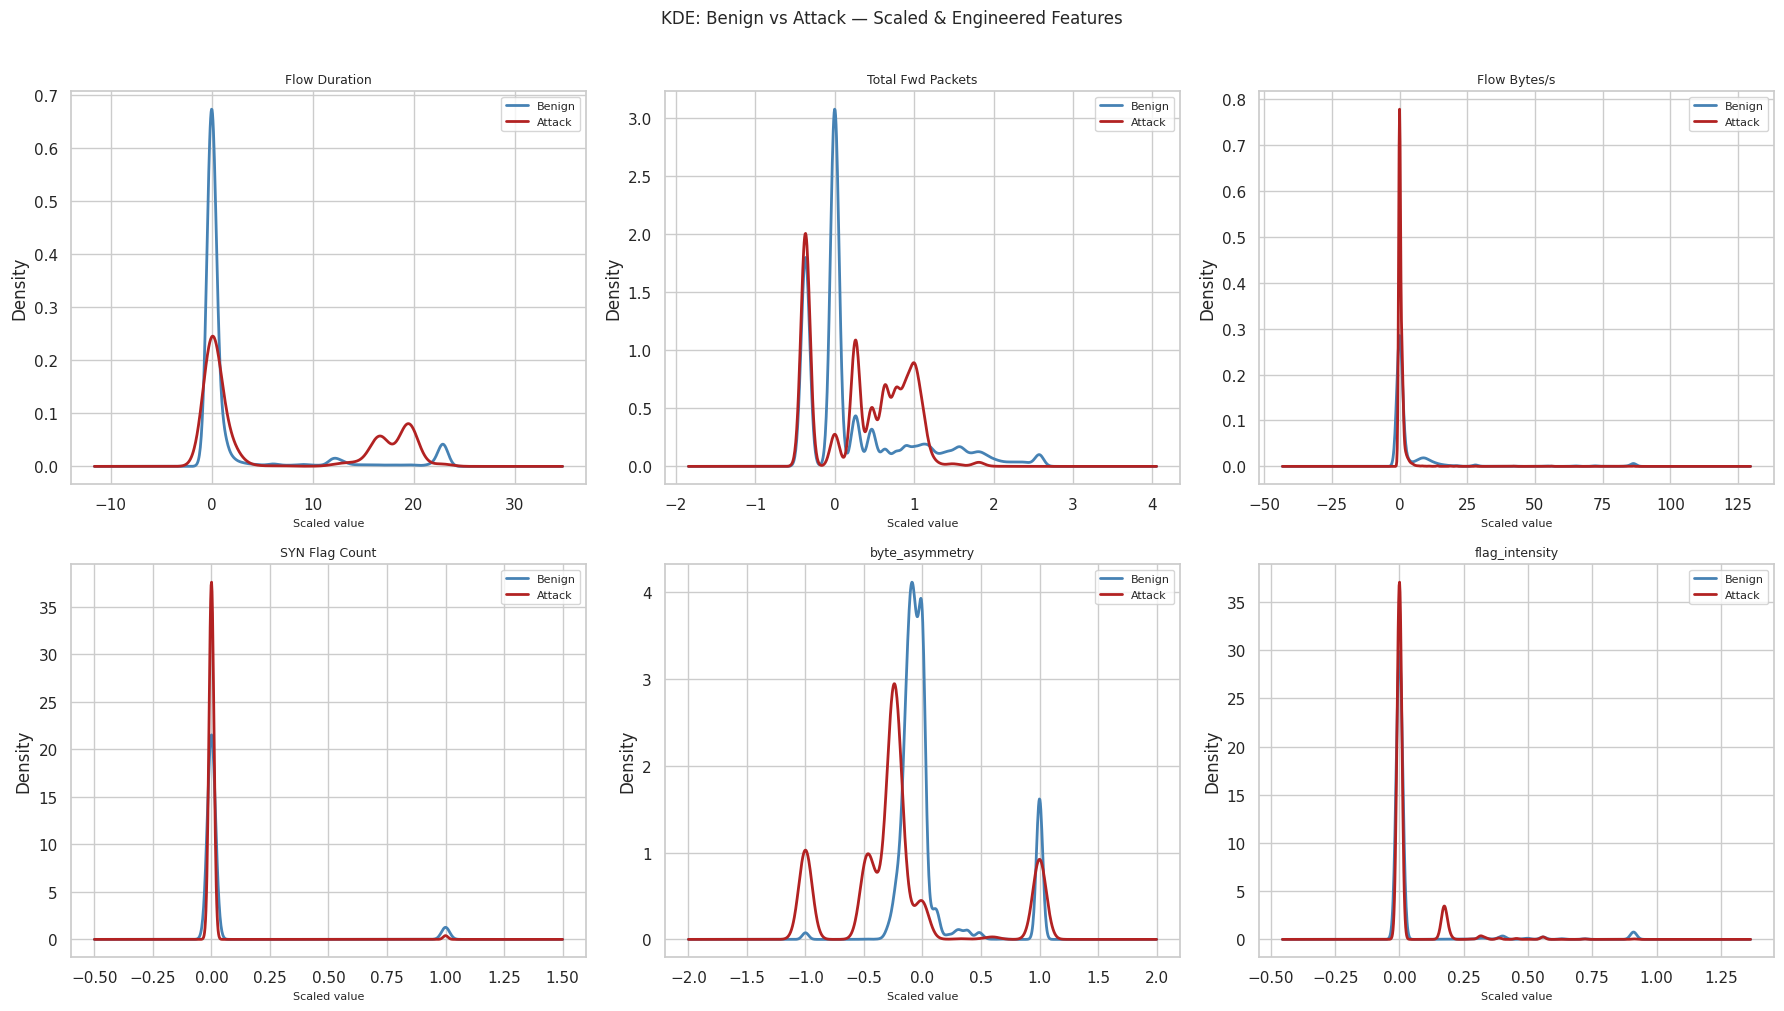

In [15]:
# Compare feature distributions before/after log transform for top skewed features
# Note: df holds log-transformed raw values; df_scaled holds RobustScaled values

sample_features = [
    f for f in ['Flow Duration', 'Total Fwd Packets', 'Flow Bytes/s',
                'SYN Flag Count', 'byte_asymmetry', 'flag_intensity']
    if f in df_scaled.columns
][:6]

label_binary = df['label_binary'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(sample_features):
    ax = axes[i]
    benign = df_scaled.loc[label_binary == 0, col].dropna()
    attack = df_scaled.loc[label_binary == 1, col].dropna()
    # Clip to 1st–99th percentile for readability
    lo, hi = np.percentile(pd.concat([benign, attack]), [1, 99])
    benign.clip(lo, hi).plot.kde(ax=ax, label='Benign', color='steelblue', linewidth=2)
    attack.clip(lo, hi).plot.kde(ax=ax, label='Attack', color='firebrick', linewidth=2)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=8)
    ax.set_xlabel('Scaled value', fontsize=8)

plt.suptitle('KDE: Benign vs Attack — Scaled & Engineered Features', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions_scaled.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Correlation Heatmap (Top 25 Features)

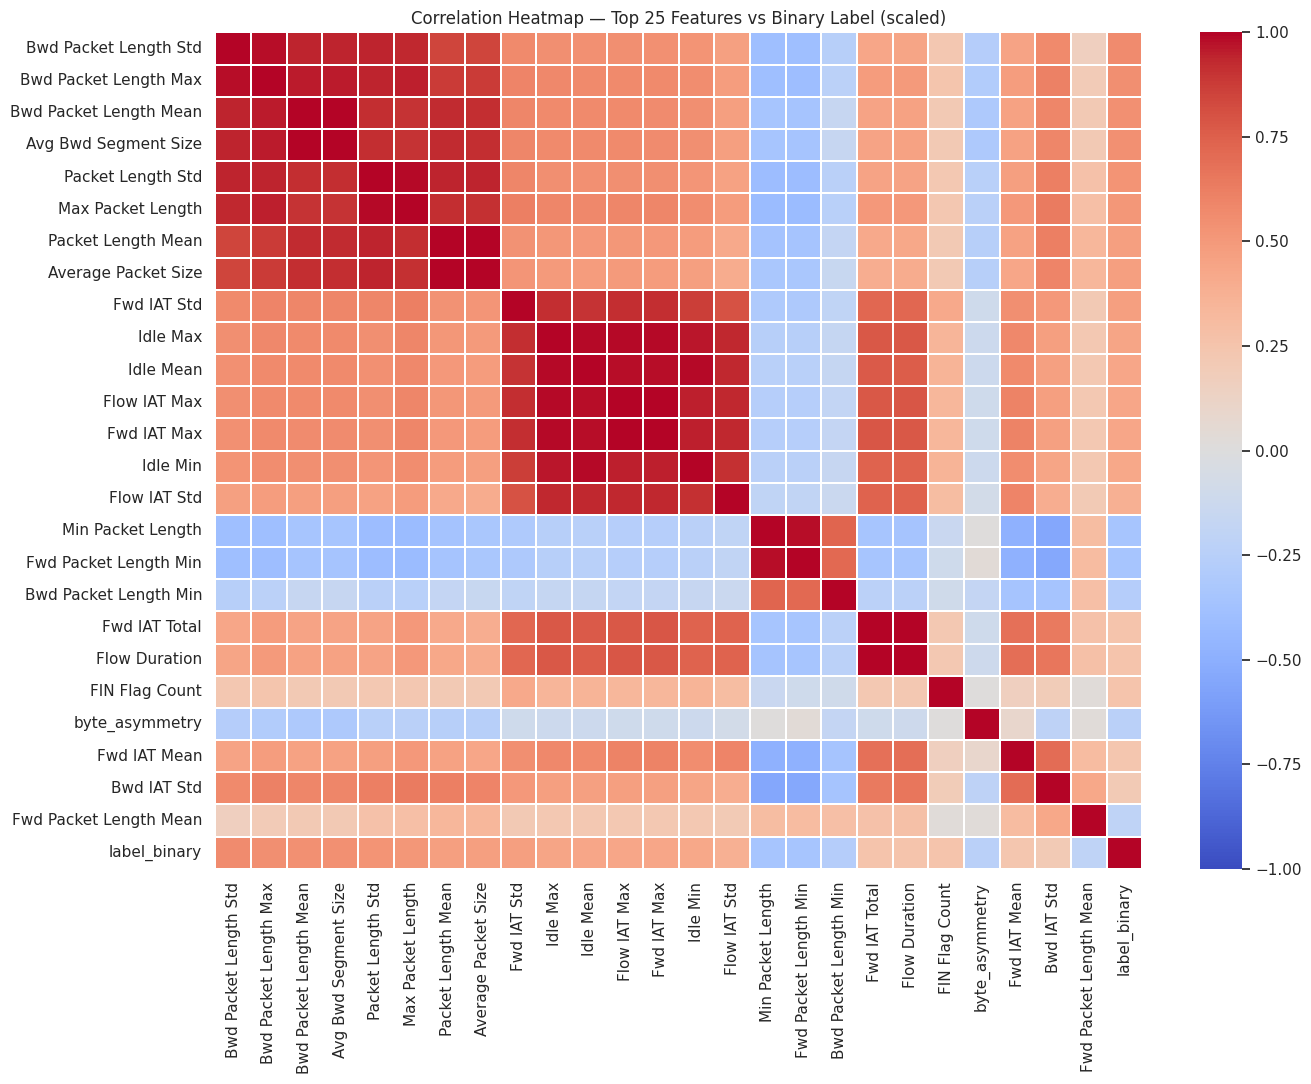

Top 10 features by correlation with binary label:


,|corr|
Bwd Packet Length Std,0.5674
Bwd Packet Length Max,0.5513
Bwd Packet Length Mean,0.5466
Avg Bwd Segment Size,0.5466
Packet Length Std,0.5284
Max Packet Length,0.5120
Packet Length Mean,0.4746
Average Packet Size,0.4746
Fwd IAT Std,0.4715
Idle Max,0.4416


In [16]:
df_corr_input = df_scaled[all_features].copy()
df_corr_input['label_binary'] = label_binary

corr_with_label = df_corr_input.corr()['label_binary'].drop('label_binary').abs()
top25_features = corr_with_label.sort_values(ascending=False).head(25).index.tolist()

plt.figure(figsize=(14, 11))
sns.heatmap(
    df_corr_input[top25_features + ['label_binary']].corr(),
    annot=False, cmap='coolwarm', center=0, linewidths=0.3, vmin=-1, vmax=1
)
plt.title('Correlation Heatmap — Top 25 Features vs Binary Label (scaled)', fontsize=12)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features by correlation with binary label:')
display(corr_with_label.sort_values(ascending=False).head(10).to_frame('|corr|'))

### 5.3 Attack Category Feature Profiles

Radar/strip plots showing how each attack type differs in key feature dimensions.

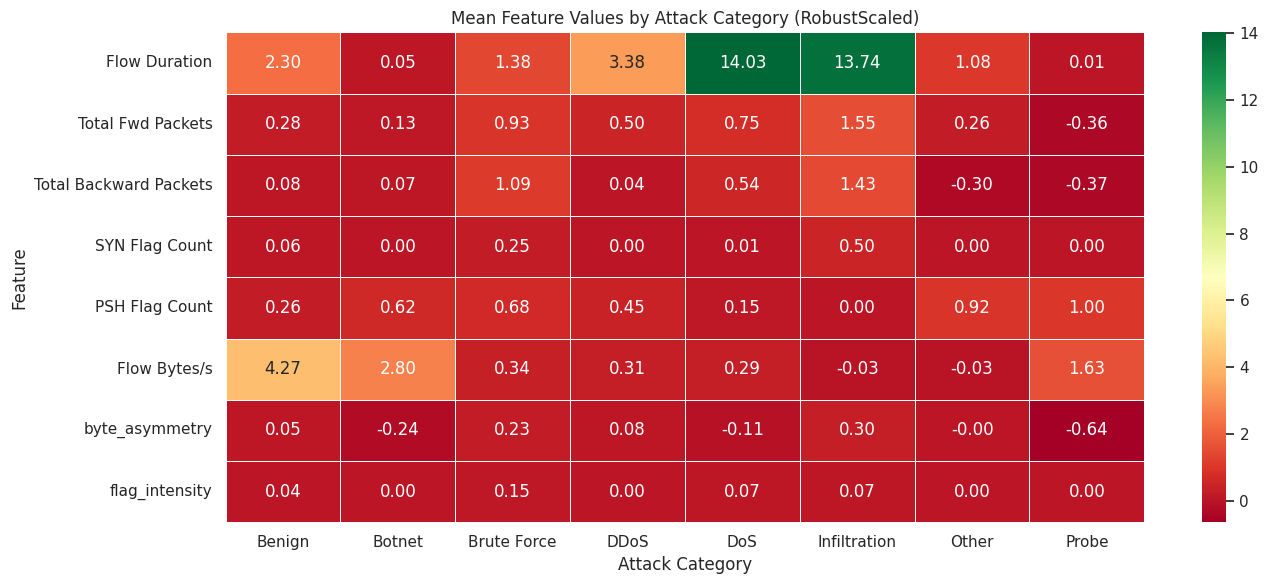

In [17]:
# Mean feature values per attack category for a set of discriminative features
profile_features = [
    f for f in ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
                'SYN Flag Count', 'PSH Flag Count', 'Flow Bytes/s',
                'byte_asymmetry', 'flag_intensity']
    if f in df_scaled.columns
]

df_profile = df_scaled[profile_features].copy()
df_profile['attack_category'] = df['attack_category'].values

# Clip extreme values for cleaner viz
for col in profile_features:
    p1, p99 = np.percentile(df_profile[col].dropna(), [1, 99])
    df_profile[col] = df_profile[col].clip(p1, p99)

category_means = df_profile.groupby('attack_category')[profile_features].mean()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    category_means.T,
    cmap='RdYlGn', linewidths=0.5, annot=True, fmt='.2f', ax=ax
)
ax.set_title('Mean Feature Values by Attack Category (RobustScaled)', fontsize=12)
ax.set_xlabel('Attack Category')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('eda_attack_profile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Pairplot — Top 5 Discriminative Features

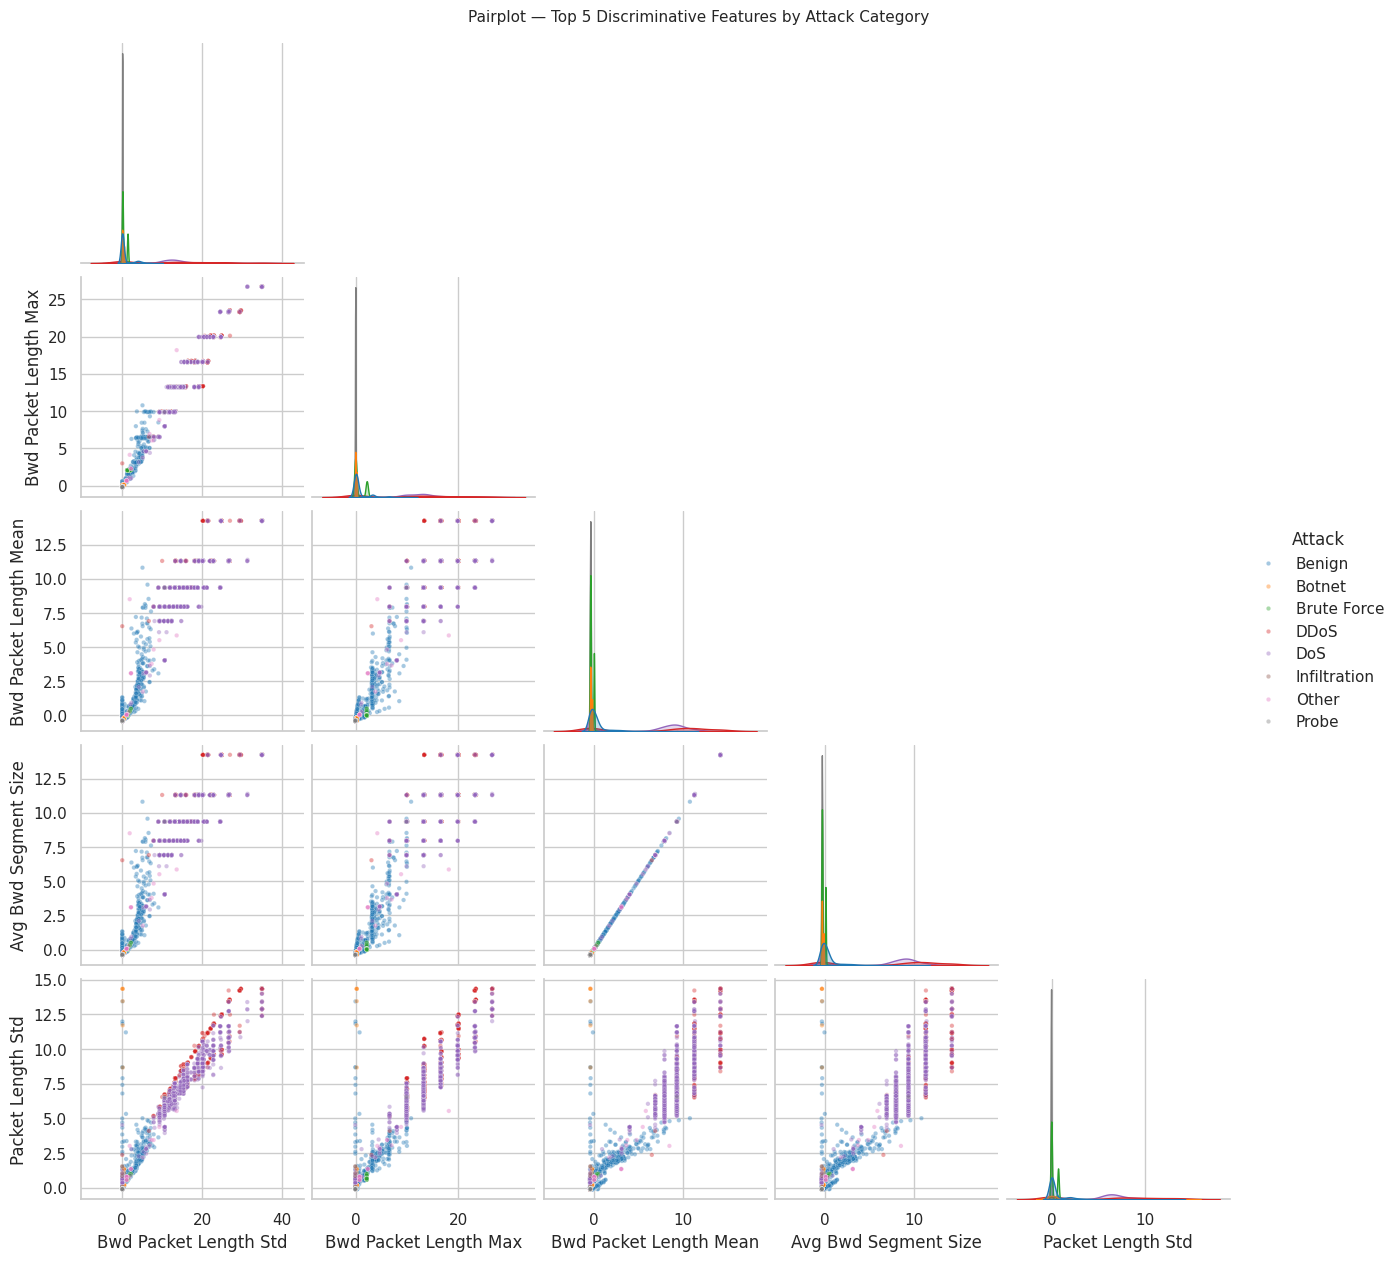

In [18]:
top5_features = corr_with_label.sort_values(ascending=False).head(5).index.tolist()

# Downsample for speed
pairplot_df = df_scaled[top5_features].copy()
pairplot_df['Attack'] = df['attack_category'].values
pairplot_df = pairplot_df.groupby('Attack', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 1500), random_state=RANDOM_SEED)
)

# Clip outliers for readability
for col in top5_features:
    p1, p99 = np.percentile(pairplot_df[col].dropna(), [1, 99])
    pairplot_df[col] = pairplot_df[col].clip(p1, p99)

g = sns.pairplot(
    pairplot_df, hue='Attack', corner=True, plot_kws={'alpha': 0.4, 's': 10},
    palette=sns.color_palette('tab10', n_colors=pairplot_df['Attack'].nunique())
)
g.fig.suptitle('Pairplot — Top 5 Discriminative Features by Attack Category', y=1.01, fontsize=11)
plt.savefig('eda_pairplot_top5.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Feature Importance & SHAP Explainability

A RandomForest is trained on a stratified subsample to compute SHAP values. This serves two purposes: it ranks features by actual predictive contribution (not just linear correlation), and it produces the explainability output required for Step 5.

In [19]:
from sklearn.model_selection import train_test_split

# Subsample for SHAP speed — 20k rows, stratified by binary label
SHAP_SAMPLE = 20_000

X_all = df_scaled[all_features].values
y_all = df['label_binary'].values

X_sub, _, y_sub, _ = train_test_split(
    X_all, y_all, train_size=min(SHAP_SAMPLE, len(X_all)),
    stratify=y_all, random_state=RANDOM_SEED
)

print(f'SHAP subsample: {X_sub.shape[0]:,} rows')
print(f'Class balance: {pd.Series(y_sub).value_counts().to_dict()}')

SHAP subsample: 20,000 rows
Class balance: {0: 16410, 1: 3590}


In [20]:
# Train a lightweight RandomForest on the subsample
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, n_jobs=-1,
    class_weight='balanced', random_state=RANDOM_SEED
)
rf.fit(X_sub, y_sub)
print('RandomForest trained on subsample.')

# Compute SHAP values (TreeExplainer is fast for RF)
explainer = shap.TreeExplainer(rf)

# Use a smaller background set for speed
shap_background = X_sub[:500]
shap_values = explainer.shap_values(shap_background)

# shap_values is a list [class0, class1] for binary classification
if isinstance(shap_values, list):
    shap_attack = shap_values[1]   # SHAP values for the attack class
else:
    shap_attack = shap_values

print(f'SHAP values computed. Shape: {shap_attack.shape}')

RandomForest trained on subsample.
SHAP values computed. Shape: (500, 71, 2)


<Figure size 1000x800 with 0 Axes>

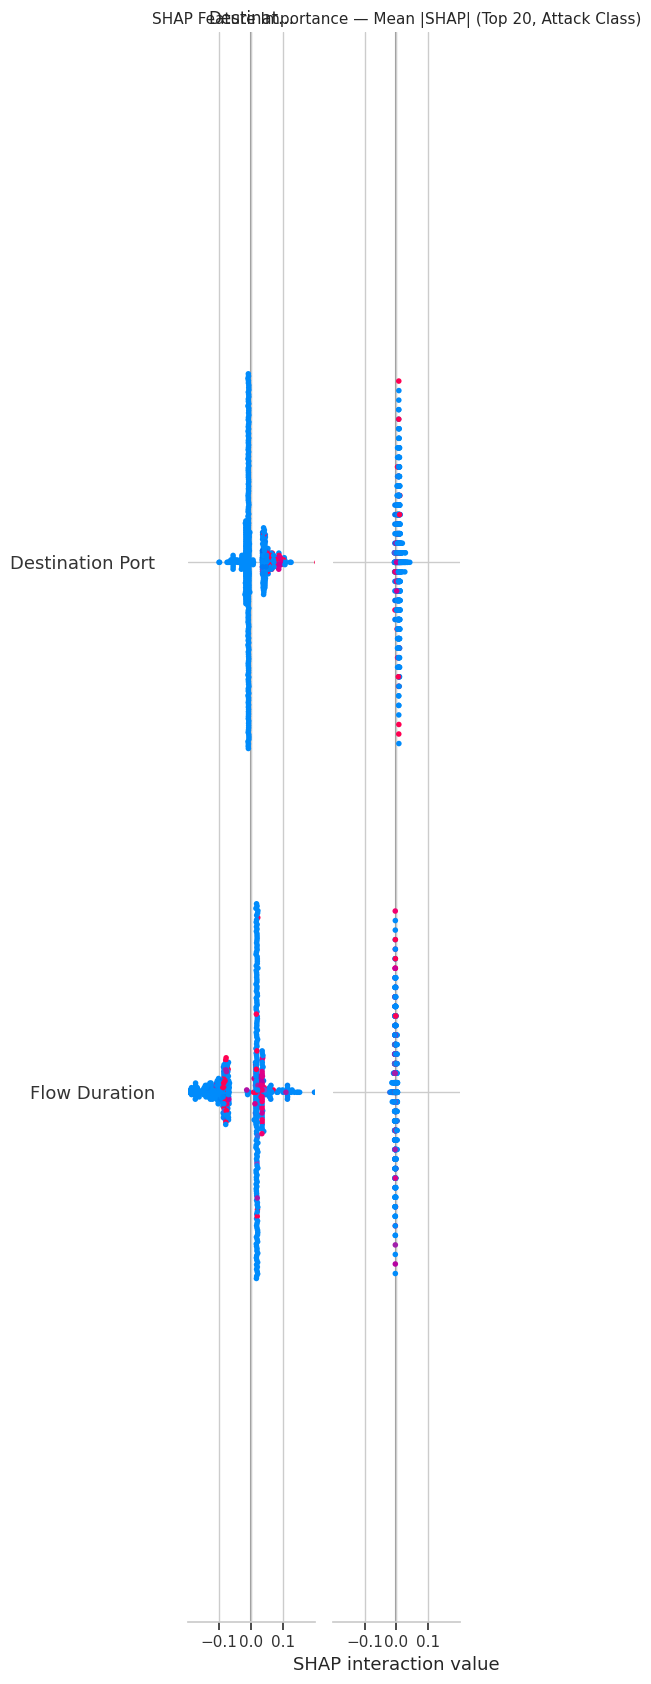

In [21]:
# SHAP Summary Plot — Bar (mean |SHAP|)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_attack, shap_background,
    feature_names=all_features,
    plot_type='bar', max_display=20, show=False
)
plt.title('SHAP Feature Importance — Mean |SHAP| (Top 20, Attack Class)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1000x800 with 0 Axes>

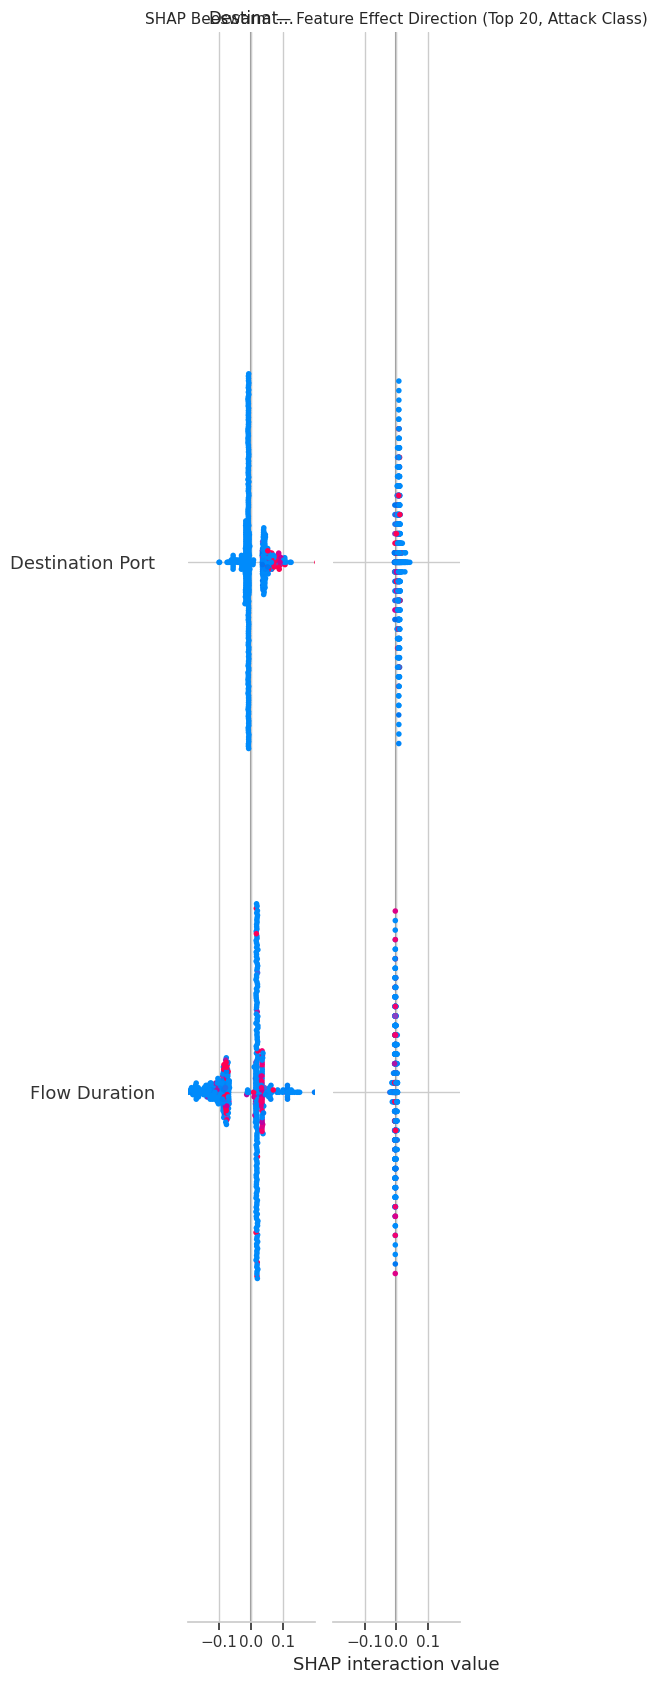

In [22]:
# SHAP Beeswarm Plot — shows direction and magnitude of feature effects
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_attack, shap_background,
    feature_names=all_features,
    plot_type='dot', max_display=20, show=False
)
plt.title('SHAP Beeswarm — Feature Effect Direction (Top 20, Attack Class)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Extract SHAP-ranked feature importance for use in feature selection
if shap_attack.ndim == 3:
    mean_shap = np.abs(shap_attack[:, :, 1]).mean(axis=0)
else:
    mean_shap = np.abs(shap_attack).mean(axis=0)
shap_importance = pd.Series(mean_shap, index=all_features).sort_values(ascending=False)

print('Top 20 features by mean |SHAP| value:')
display(shap_importance.head(20).to_frame('Mean |SHAP|').round(5))

# Save SHAP importance ranking
shap_importance.to_csv('./models/shap_feature_importance.csv', header=True)
print('\nSaved: ./models/shap_feature_importance.csv')

Top 20 features by mean |SHAP| value:


,Mean |SHAP|
byte_asymmetry,0.0360
Destination Port,0.0318
Bwd Packet Length Std,0.0312
Bwd Packet Length Mean,0.0271
Packet Length Std,0.0265
Average Packet Size,0.0236
Total Length of Bwd Packets,0.0211
Max Packet Length,0.0172
Avg Fwd Segment Size,0.0172
Subflow Bwd Bytes,0.0169



Saved: ./models/shap_feature_importance.csv


## 7. Feature Selection

Three complementary methods are applied in sequence:
1. **Variance Threshold (filter)** — removes features with near-zero variance after scaling
2. **Correlation filter** — removes one of any pair of features with |corr| > 0.95 (redundancy removal)
3. **SHAP-based selection (embedded-equivalent)** — retains top-N features by SHAP importance

In [25]:
# ── Step 1: Variance Threshold ────────────────────────────────────────────────
vt = VarianceThreshold(threshold=0.01)
vt.fit(df_scaled[all_features])
features_after_vt = [f for f, keep in zip(all_features, vt.get_support()) if keep]

dropped_vt = [f for f in all_features if f not in features_after_vt]
print(f'Variance Threshold (>0.01): dropped {len(dropped_vt)} features')
print(f'  Dropped: {dropped_vt}')
print(f'  Remaining: {len(features_after_vt)}')

Variance Threshold (>0.01): dropped 0 features
  Dropped: []
  Remaining: 71


In [26]:
# ── Step 2: Correlation Filter ────────────────────────────────────────────────
# Remove one of any feature pair with |Pearson correlation| > 0.95
# Keep the one with higher SHAP importance

corr_matrix = df_scaled[features_after_vt].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# For each high-corr pair, drop the one with lower SHAP importance
to_drop_corr = set()
for col in upper_tri.columns:
    high_corr_pairs = upper_tri.index[upper_tri[col] > 0.95].tolist()
    for partner in high_corr_pairs:
        shap_col     = shap_importance.get(col, 0)
        shap_partner = shap_importance.get(partner, 0)
        # Drop the one with lower SHAP importance
        to_drop_corr.add(col if shap_col < shap_partner else partner)

features_after_corr = [f for f in features_after_vt if f not in to_drop_corr]
print(f'Correlation filter (|r|>0.95): dropped {len(to_drop_corr)} features')
print(f'  Remaining: {len(features_after_corr)}')

Correlation filter (|r|>0.95): dropped 20 features
  Remaining: 51


In [27]:
# ── Step 3: SHAP-Based Top-N Selection ───────────────────────────────────────
# Keep the top 40 features by mean |SHAP| from the correlation-filtered set
TOP_N = 40

shap_ranked_remaining = shap_importance[shap_importance.index.isin(features_after_corr)]
selected_features = shap_ranked_remaining.head(TOP_N).index.tolist()

print(f'Final selected features (SHAP top-{TOP_N} from filtered set): {len(selected_features)}')
print(selected_features)

# Save selected features list
pd.Series(selected_features).to_csv('./models/selected_features.csv', index=False, header=['feature'])
print('\nSaved: ./models/selected_features.csv')

Final selected features (SHAP top-40 from filtered set): 40
['byte_asymmetry', 'Destination Port', 'Bwd Packet Length Std', 'Bwd Packet Length Mean', 'Packet Length Std', 'Average Packet Size', 'Total Length of Bwd Packets', 'Avg Fwd Segment Size', 'payload_header_ratio_fwd', 'Packet Length Variance', 'Init_Win_bytes_backward', 'Bwd Packet Length Min', 'Bwd Header Length', 'Init_Win_bytes_forward', 'PSH Flag Count', 'Fwd Packet Length Max', 'Total Backward Packets', 'pkt_asymmetry', 'Bwd Packets/s', 'Fwd Header Length', 'Min Packet Length', 'Flow Bytes/s', 'Flow IAT Mean', 'Total Fwd Packets', 'Flow IAT Std', 'ACK Flag Count', 'Fwd IAT Mean', 'Fwd IAT Max', 'Flow Duration', 'Fwd IAT Std', 'Fwd Packets/s', 'min_seg_size_forward', 'Fwd Packet Length Std', 'URG Flag Count', 'Flow Packets/s', 'Bwd IAT Total', 'act_data_pkt_fwd', 'Flow IAT Min', 'duration_bin', 'Fwd IAT Min']

Saved: ./models/selected_features.csv


In [28]:
# Final feature matrix
X_selected = df_scaled[selected_features].values
y = df['label_binary'].values
y_multiclass = LabelEncoder().fit_transform(df['attack_category'].values)

print(f'Final feature matrix X: {X_selected.shape}')
print(f'Target y (binary): {np.unique(y, return_counts=True)}')

# Save for Step 4
np.save('./models/X_selected.npy', X_selected)
np.save('./models/y_binary.npy', y)
np.save('./models/y_multiclass.npy', y_multiclass)
joblib.dump(df['attack_category'].values, './models/y_category_labels.pkl')
print('Saved X_selected.npy, y_binary.npy, y_multiclass.npy to ./models/')

Final feature matrix X: (467589, 40)
Target y (binary): (array([0, 1], dtype=int8), array([383649,  83940]))
Saved X_selected.npy, y_binary.npy, y_multiclass.npy to ./models/


## 8. Dimensionality Reduction

### 8.1 PCA — Variance Explained

Components to explain 95% variance: 3
Components to explain 99% variance: 3


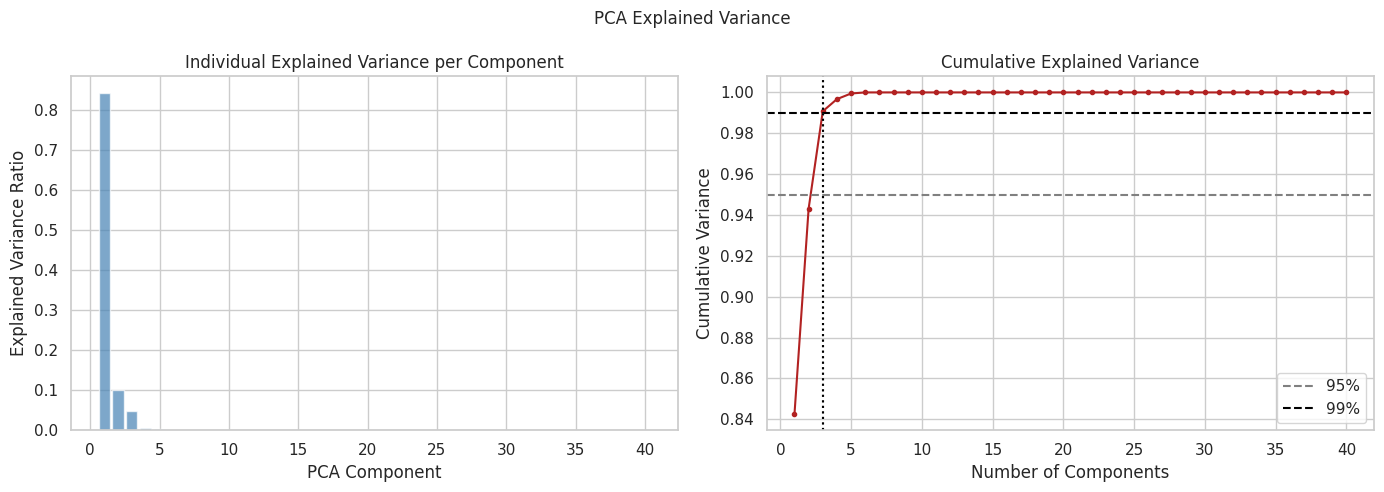

In [29]:
# PCA on the full selected feature set
pca_full = PCA(random_state=RANDOM_SEED)
pca_full.fit(X_selected)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95   = np.searchsorted(cumvar, 0.95) + 1
n_99   = np.searchsorted(cumvar, 0.99) + 1

print(f'Components to explain 95% variance: {n_95}')
print(f'Components to explain 99% variance: {n_99}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[0].set_title('Individual Explained Variance per Component')
axes[0].set_xlabel('PCA Component')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(range(1, len(cumvar) + 1), cumvar, marker='.', color='firebrick')
axes[1].axhline(0.95, color='gray', linestyle='--', label='95%')
axes[1].axhline(0.99, color='black', linestyle='--', label='99%')
axes[1].axvline(n_95, color='gray', linestyle=':')
axes[1].axvline(n_99, color='black', linestyle=':')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()

plt.suptitle('PCA Explained Variance', fontsize=12)
plt.tight_layout()
plt.savefig('pca_variance_explained.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Fit PCA retaining 95% variance and save
pca_95 = PCA(n_components=n_95, random_state=RANDOM_SEED)
X_pca = pca_95.fit_transform(X_selected)

joblib.dump(pca_95, './models/pca_95.pkl')
np.save('./models/X_pca.npy', X_pca)

print(f'PCA (95% variance): {X_selected.shape[1]} features -> {X_pca.shape[1]} components')
print('Saved pca_95.pkl and X_pca.npy to ./models/')

PCA (95% variance): 40 features -> 3 components
Saved pca_95.pkl and X_pca.npy to ./models/


### 8.2 PCA 2D Scatter — Attack Category Separation

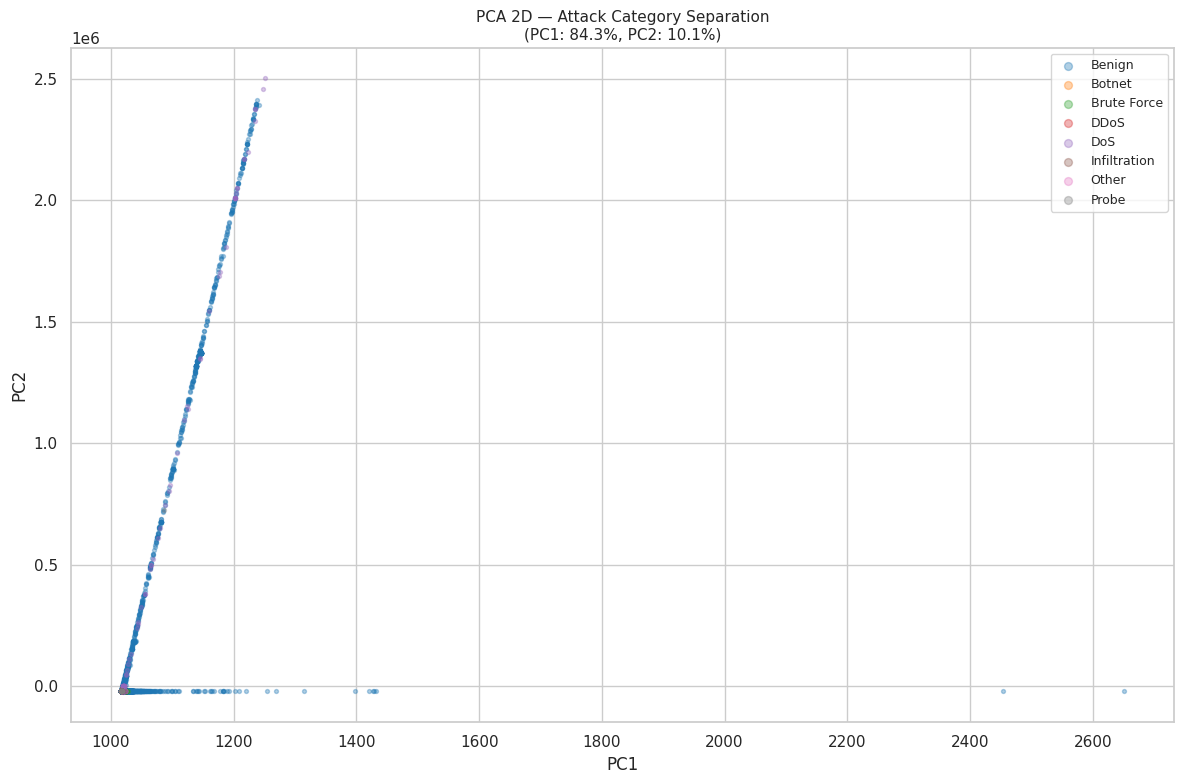

In [31]:
# 2D PCA projection for visualisation
pca_2d = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca_2d = pca_2d.fit_transform(X_selected)

attack_categories = df['attack_category'].values
unique_cats = sorted(set(attack_categories))
palette = sns.color_palette('tab10', n_colors=len(unique_cats))
cat_color = {cat: palette[i] for i, cat in enumerate(unique_cats)}

# Downsample for plot speed
plot_idx = np.random.choice(len(X_pca_2d), size=min(30_000, len(X_pca_2d)), replace=False)

fig, ax = plt.subplots(figsize=(12, 8))
for cat in unique_cats:
    mask = attack_categories[plot_idx] == cat
    ax.scatter(
        X_pca_2d[plot_idx][mask, 0], X_pca_2d[plot_idx][mask, 1],
        label=cat, alpha=0.35, s=8, color=cat_color[cat]
    )

ax.set_title(
    f'PCA 2D — Attack Category Separation\n'
    f'(PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}%, '
    f'PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11
)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(markerscale=2, fontsize=9, loc='best')
plt.tight_layout()
plt.savefig('pca_2d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 t-SNE 2D Visualisation

t-SNE preserves local neighbourhood structure and often reveals cluster separation that PCA misses because it is non-linear. Run on PCA-reduced data (n_95 components) for speed.

In [32]:
# t-SNE is expensive — use a 10k stratified sample
TSNE_SAMPLE = 10_000

tsne_idx = []
attack_cats_arr = df['attack_category'].values
for cat in unique_cats:
    cat_idx = np.where(attack_cats_arr == cat)[0]
    n_take = max(1, int(TSNE_SAMPLE * len(cat_idx) / len(attack_cats_arr)))
    tsne_idx.extend(np.random.choice(cat_idx, size=min(n_take, len(cat_idx)), replace=False))

tsne_idx = np.array(tsne_idx)
X_tsne_input = X_pca[:min(len(tsne_idx), TSNE_SAMPLE)]  # use PCA-reduced for speed
X_tsne_input = X_pca[tsne_idx[:TSNE_SAMPLE]]
y_tsne_cats  = attack_cats_arr[tsne_idx[:TSNE_SAMPLE]]

print(f't-SNE input shape: {X_tsne_input.shape}')

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
            random_state=RANDOM_SEED, n_jobs=-1)
X_tsne = tsne.fit_transform(X_tsne_input)

print('t-SNE complete.')

t-SNE input shape: (9998, 3)
t-SNE complete.


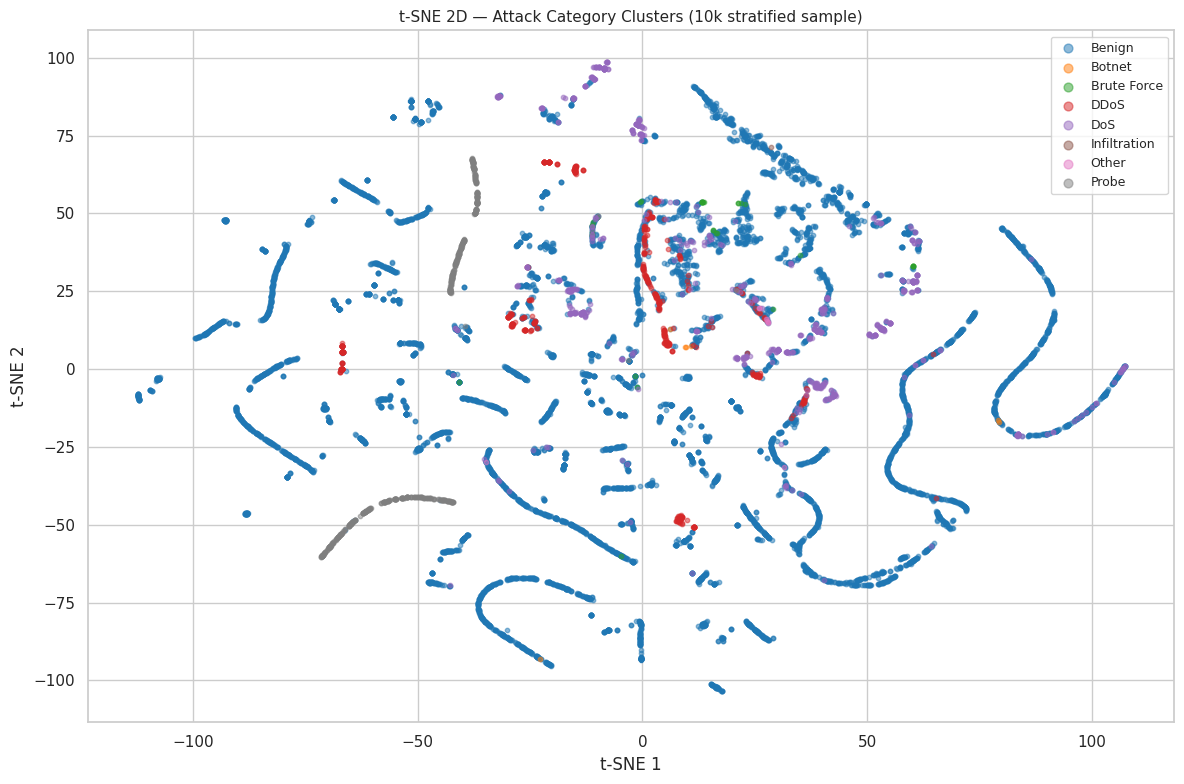

In [33]:
fig, ax = plt.subplots(figsize=(12, 8))
for cat in unique_cats:
    mask = y_tsne_cats == cat
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        label=cat, alpha=0.5, s=10, color=cat_color[cat]
    )

ax.set_title('t-SNE 2D — Attack Category Clusters (10k stratified sample)', fontsize=11)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(markerscale=2, fontsize=9, loc='best')
plt.tight_layout()
plt.savefig('tsne_2d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Preprocessing Summary

In [34]:
print('=== STEP 3 PREPROCESSING & FEATURE ENGINEERING SUMMARY ===')
print()
print(f'Original dataset         : ~500,000 rows x ~78 numeric features')
print(f'After deduplication      : {len(df):,} rows')
print(f'After NaN removal        : {len(df):,} rows (negligible NaN fraction)')
print(f'After zero-var drop      : {len(numeric_cols)} features')
print(f'Log1p applied to         : {len(log_transformed)} high-skew features')
print(f'Inf values treated       : capped at 99.9th percentile')
print(f'Scaler                   : RobustScaler (saved to ./models/robust_scaler.pkl)')
print()
print(f'Engineered features      : {eng_features}')
print(f'Total features before selection: {len(all_features)}')
print()
print(f'Feature selection pipeline:')
print(f'  1. Variance Threshold  : {len(all_features)} -> {len(features_after_vt)}')
print(f'  2. Correlation Filter  : {len(features_after_vt)} -> {len(features_after_corr)}')
print(f'  3. SHAP Top-{TOP_N}        : {len(features_after_corr)} -> {len(selected_features)}')
print()
print(f'PCA (95% variance)       : {len(selected_features)} features -> {n_95} components')
print()
print('Artefacts saved to ./models/:')
for fname in os.listdir('./models/'):
    fpath = f'./models/{fname}'
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {fname:<35} {size_kb:.1f} KB')

=== STEP 3 PREPROCESSING & FEATURE ENGINEERING SUMMARY ===

Original dataset         : ~500,000 rows x ~78 numeric features
After deduplication      : 467,589 rows
After NaN removal        : 467,589 rows (negligible NaN fraction)
After zero-var drop      : 66 features
Log1p applied to         : 29 high-skew features
Inf values treated       : capped at 99.9th percentile
Scaler                   : RobustScaler (saved to ./models/robust_scaler.pkl)

Engineered features      : ['byte_asymmetry', 'pkt_asymmetry', 'flag_intensity', 'payload_header_ratio_fwd', 'duration_bin']
Total features before selection: 71

Feature selection pipeline:
  1. Variance Threshold  : 71 -> 71
  2. Correlation Filter  : 71 -> 51
  3. SHAP Top-40        : 51 -> 40

PCA (95% variance)       : 40 features -> 3 components

Artefacts saved to ./models/:
  y_category_labels.pkl               916.9 KB
  X_selected.npy                      146121.7 KB
  y_multiclass.npy                    3653.2 KB
  y_binary.npy     